In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
#os.chdir("/content/drive/MyDrive/Datasets")
os.chdir("/content/drive/MyDrive/engage2/Internship project")
!ls

cleaned_URT.xlsx
logistic_regression_model.joblib
Upper_Respiratory_Tract_Infection_With_Symptoms.xlsx


In [4]:
data=pd.read_excel("/content/drive/MyDrive/engage2/Internship project/Upper_Respiratory_Tract_Infection_With_Symptoms.xlsx")
data.head()

,Patient ID,Visit Date,Name,Age,Gender,Phone Number,Fever,Cough,Runny nose,Sore throat,Shortness of breath,Primary Coded Diagnosis
0,1,06 May 2025,Abdakadir Omar,7.0,male,0703681383,1,0,1,0,0,Upper Respiratory Infection
1,2,25 Jul 2025,Abdirahaman Hussein,8.0,male,0798948751,1,1,0,0,0,Upper Respiratory Infection
2,3,24 Mar 2025,Abdirahim Ali Mohamed,21.0,male,07245058+0,1,0,1,0,0,Upper Respiratory Infection
3,4,03 Jul 2025,Abdirahman Sharmake,7.0,male,0742191486,1,1,1,0,0,Upper Respiratory Infection
4,5,11 Sep 2025,Abigael Muthoni,3.0,female,0769549859,1,1,1,0,0,Upper Respiratory Infection


In [5]:
data.isnull().sum()

,0
Patient ID,0
Visit Date,1
Name,1
Age,17
Gender,3
Phone Number,94
Fever,0
Cough,0
Runny nose,0
Sore throat,0


In [6]:
data.dropna(inplace=True)

In [7]:
data.isnull().sum()

,0
Patient ID,0
Visit Date,0
Name,0
Age,0
Gender,0
Phone Number,0
Fever,0
Cough,0
Runny nose,0
Sore throat,0


In [8]:
print(data.info())


<class 'pandas.core.frame.DataFrame'>
Index: 486 entries, 0 to 589
Data columns (total 12 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Patient ID               486 non-null    int64  
 1   Visit Date               486 non-null    object 
 2   Name                     486 non-null    object 
 3   Age                      486 non-null    float64
 4   Gender                   486 non-null    object 
 5   Phone Number             486 non-null    object 
 6   Fever                    486 non-null    int64  
 7   Cough                    486 non-null    int64  
 8   Runny nose               486 non-null    int64  
 9   Sore throat              486 non-null    int64  
 10  Shortness of breath      486 non-null    int64  
 11  Primary Coded Diagnosis  486 non-null    object 
dtypes: float64(1), int64(6), object(5)
memory usage: 49.4+ KB
None


In [9]:
print(data.describe())


       Patient ID         Age       Fever       Cough  Runny nose  \
count  486.000000  486.000000  486.000000  486.000000  486.000000   
mean   297.228395   14.368313    0.825103    0.843621    0.660494   
std    168.106665   16.964917    0.380271    0.363588    0.474030   
min      1.000000    0.000000    0.000000    0.000000    0.000000   
25%    153.500000    1.000000    1.000000    1.000000    0.000000   
50%    295.500000    6.000000    1.000000    1.000000    1.000000   
75%    443.750000   25.000000    1.000000    1.000000    1.000000   
max    590.000000   70.000000    1.000000    1.000000    1.000000   

       Sore throat  Shortness of breath  
count   486.000000           486.000000  
mean      0.222222             0.129630  
std       0.416168             0.336242  
min       0.000000             0.000000  
25%       0.000000             0.000000  
50%       0.000000             0.000000  
75%       0.000000             0.000000  
max       1.000000             1.000000  


In [10]:
data["Gender"]=pd.get_dummies(data['Gender'], dtype=int,drop_first=True)
display(data.head())

,Patient ID,Visit Date,Name,Age,Gender,Phone Number,Fever,Cough,Runny nose,Sore throat,Shortness of breath,Primary Coded Diagnosis
0,1,06 May 2025,Abdakadir Omar,7.0,1,0703681383,1,0,1,0,0,Upper Respiratory Infection
1,2,25 Jul 2025,Abdirahaman Hussein,8.0,1,0798948751,1,1,0,0,0,Upper Respiratory Infection
2,3,24 Mar 2025,Abdirahim Ali Mohamed,21.0,1,07245058+0,1,0,1,0,0,Upper Respiratory Infection
3,4,03 Jul 2025,Abdirahman Sharmake,7.0,1,0742191486,1,1,1,0,0,Upper Respiratory Infection
4,5,11 Sep 2025,Abigael Muthoni,3.0,0,0769549859,1,1,1,0,0,Upper Respiratory Infection


In [11]:
data = data.drop(['Visit Date', 'Name', 'Patient ID', 'Phone Number'], axis=1)
display(data.head())

,Age,Gender,Fever,Cough,Runny nose,Sore throat,Shortness of breath,Primary Coded Diagnosis
0,7.0,1,1,0,1,0,0,Upper Respiratory Infection
1,8.0,1,1,1,0,0,0,Upper Respiratory Infection
2,21.0,1,1,0,1,0,0,Upper Respiratory Infection
3,7.0,1,1,1,1,0,0,Upper Respiratory Infection
4,3.0,0,1,1,1,0,0,Upper Respiratory Infection


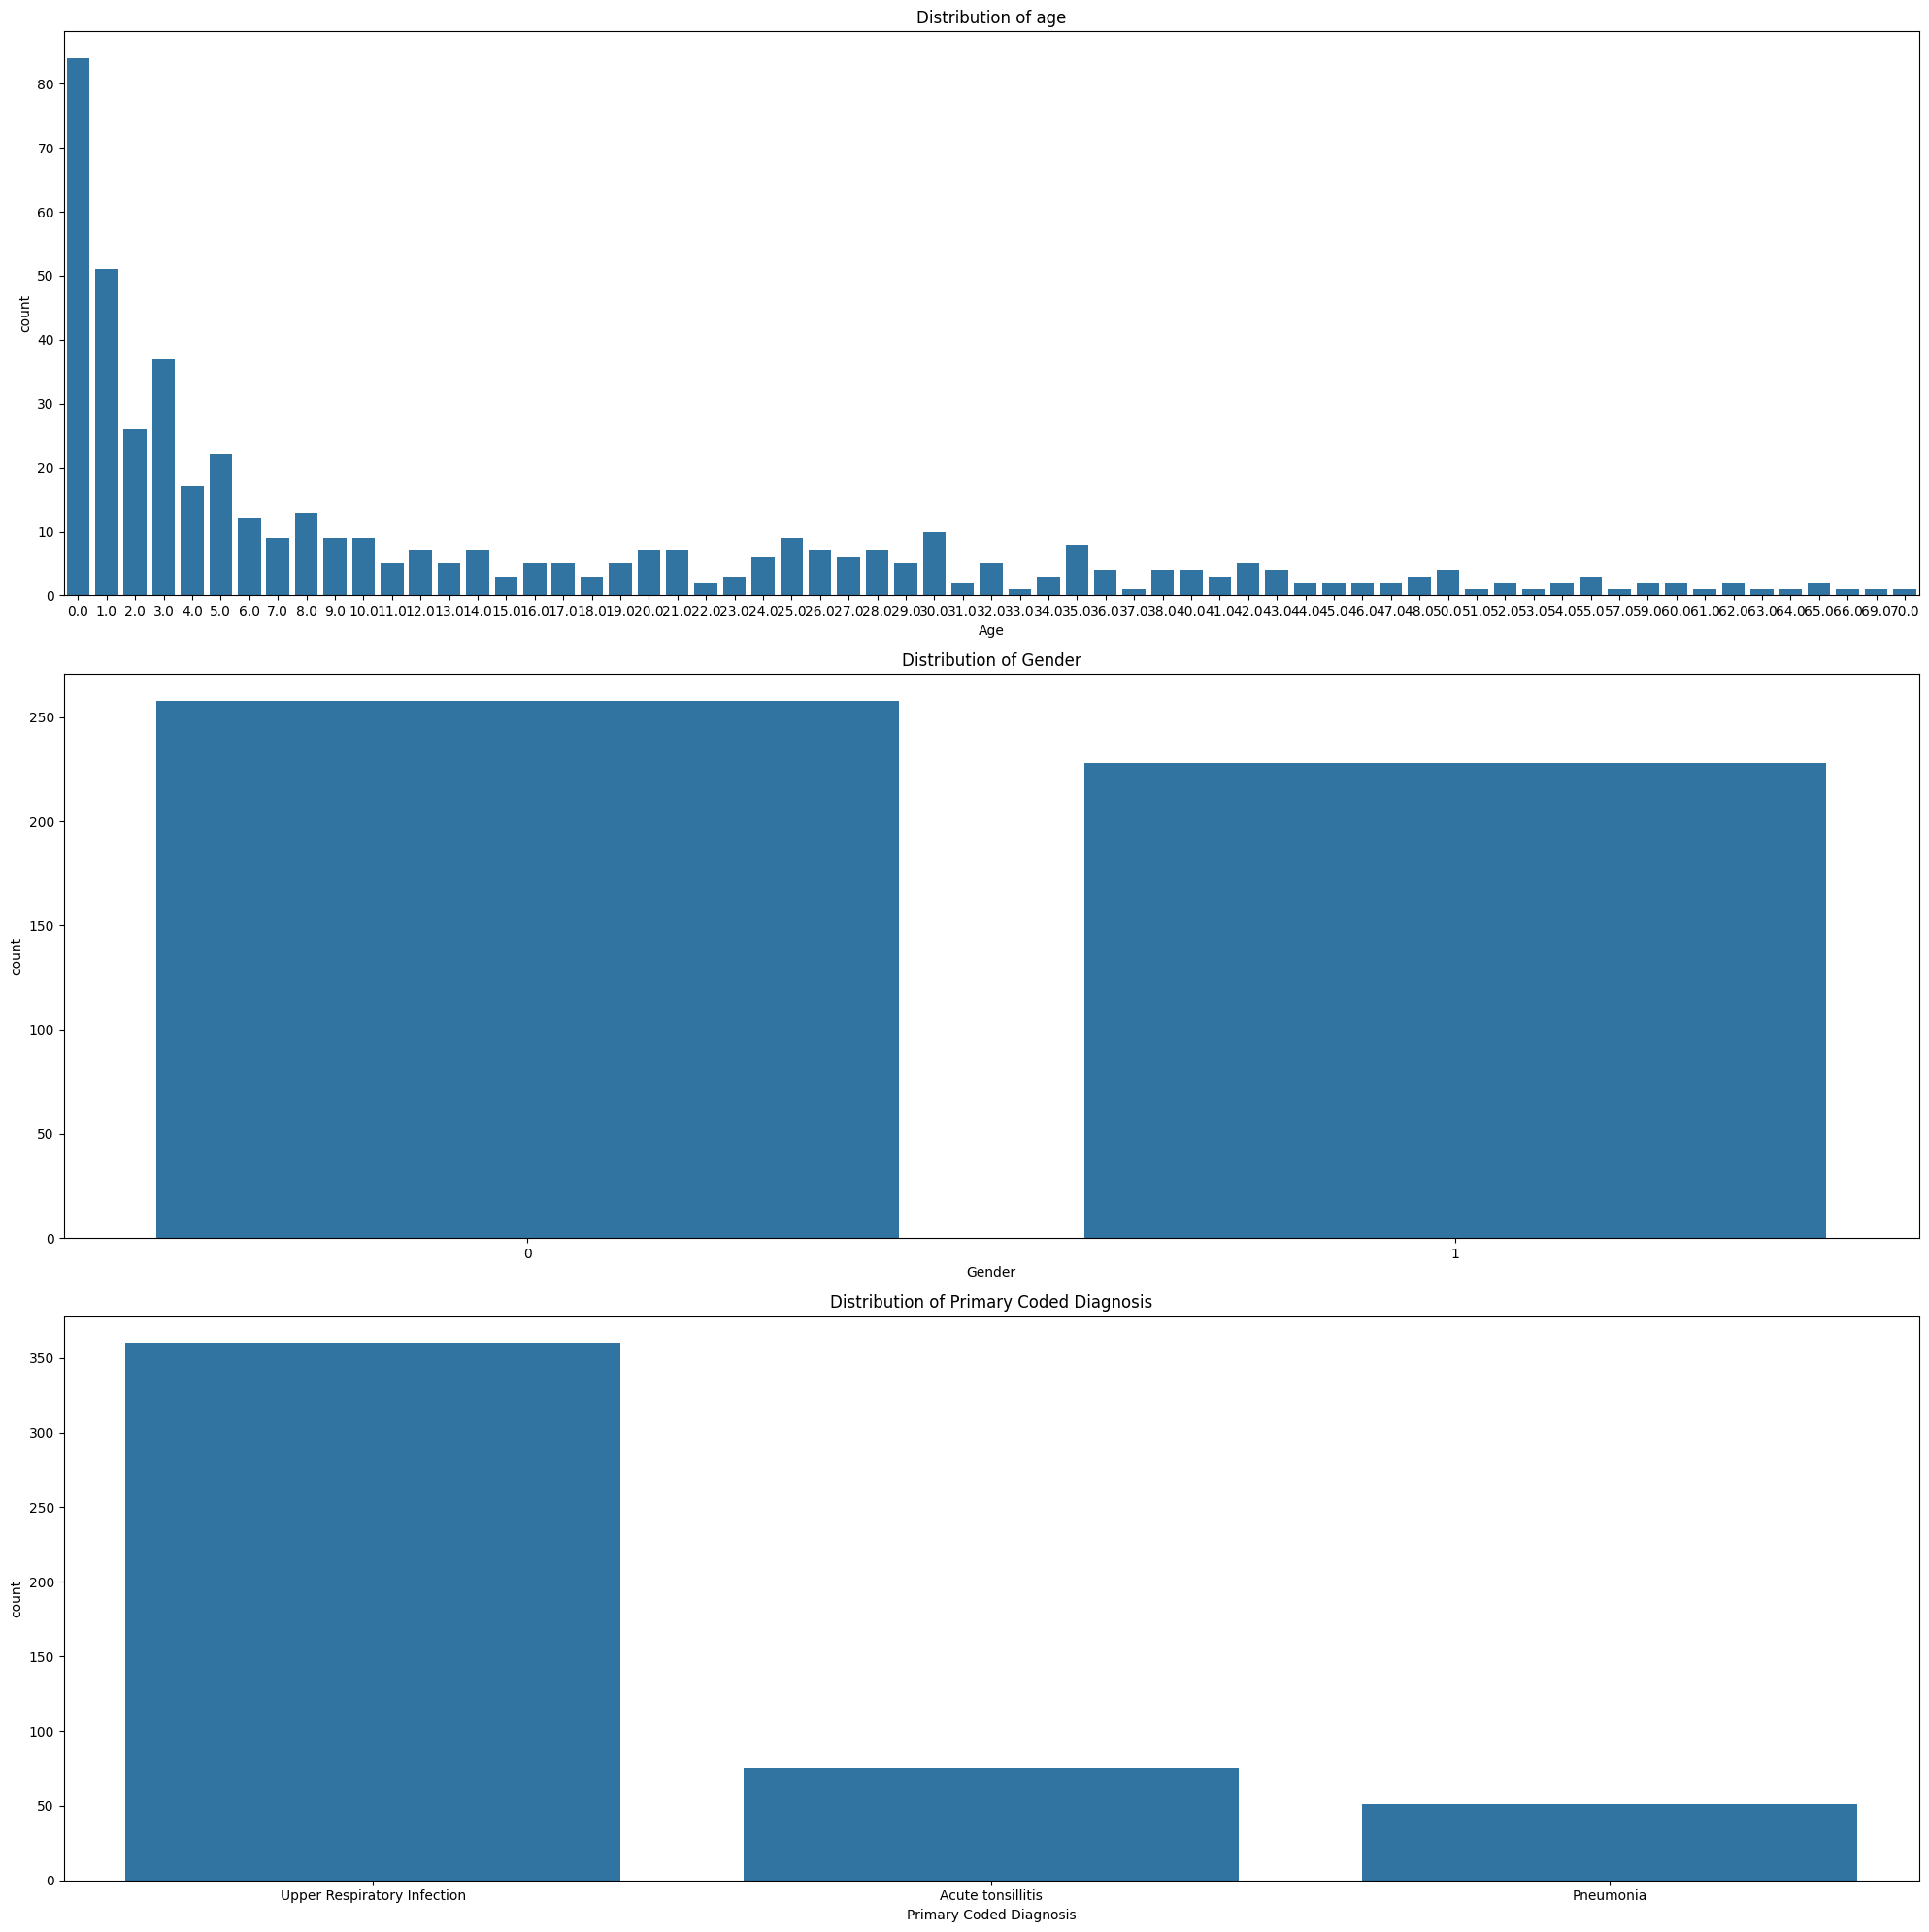

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(20, 20))

sns.countplot(x='Age', data=data, ax=axes[0])
axes[0].set_title("Distribution of age")

sns.countplot(x='Gender', data=data, ax=axes[1])
axes[1].set_title("Distribution of Gender")

sns.countplot(x='Primary Coded Diagnosis', data=data, ax=axes[2])
axes[2].set_title("Distribution of Primary Coded Diagnosis")

plt.tight_layout()
plt.show()

In [13]:
numerical_vars = data.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_vars = data.select_dtypes(include=['object', 'bool']).columns.tolist()

print("Numerical Variables:", numerical_vars)
print("Categorical Variables:", categorical_vars)

Numerical Variables: ['Age', 'Gender', 'Fever', 'Cough', 'Runny nose', 'Sore throat', 'Shortness of breath']
Categorical Variables: ['Primary Coded Diagnosis']


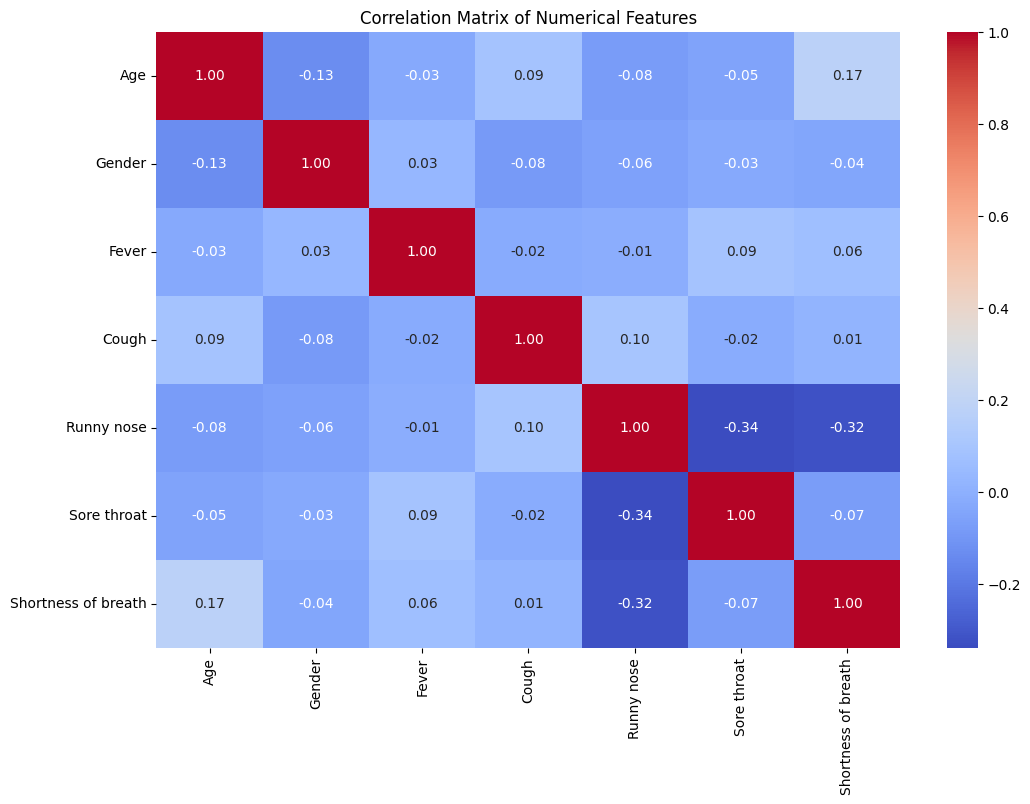

,Age,Gender,Fever,Cough,Runny nose,Sore throat,Shortness of breath
Age,1.000000,-0.130882,-0.026749,0.086239,-0.078770,-0.053670,0.174509
Gender,-0.130882,1.000000,0.031221,-0.083386,-0.057401,-0.026447,-0.043644
Fever,-0.026749,0.031221,1.000000,-0.019270,-0.009814,0.089752,0.064801
Cough,0.086239,-0.083386,-0.019270,1.000000,0.098068,-0.015140,0.014367
Runny nose,-0.078770,-0.057401,-0.009814,0.098068,1.000000,-0.337936,-0.318370
Sore throat,-0.053670,-0.026447,0.089752,-0.015140,-0.337936,1.000000,-0.073673
Shortness of breath,0.174509,-0.043644,0.064801,0.014367,-0.318370,-0.073673,1.000000


In [14]:
corr_matrix = data[numerical_vars].corr()

# Plot heatmap for correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix of Numerical Features")
plt.show()

# Display the correlation matrix
corr_matrix

In [15]:
#saving new file
data.to_excel("/content/drive/My Drive/engage2/Internship project/cleaned_URT.xlsx", index=False)

In [16]:
from scipy.stats import chi2_contingency

categorical_vars = ['Gender', 'Fever', 'Cough', 'Runny nose', 'Sore throat', 'Shortness of breath']
target_variable = 'Primary Coded Diagnosis'

for var in categorical_vars:
    contingency_table = pd.crosstab(data[var], data[target_variable])
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    print(f"Chi-squared test for {var} vs {target_variable}:")
    print(f"  Chi-squared statistic: {chi2:.4f}")
    print(f"  P-value: {p:.4f}")
    print("-" * 30)

Chi-squared test for Gender vs Primary Coded Diagnosis:
  Chi-squared statistic: 3.0917
  P-value: 0.2131
------------------------------
Chi-squared test for Fever vs Primary Coded Diagnosis:
  Chi-squared statistic: 1.2287
  P-value: 0.5410
------------------------------
Chi-squared test for Cough vs Primary Coded Diagnosis:
  Chi-squared statistic: 2.2329
  P-value: 0.3274
------------------------------
Chi-squared test for Runny nose vs Primary Coded Diagnosis:
  Chi-squared statistic: 235.6213
  P-value: 0.0000
------------------------------
Chi-squared test for Sore throat vs Primary Coded Diagnosis:
  Chi-squared statistic: 213.1572
  P-value: 0.0000
------------------------------
Chi-squared test for Shortness of breath vs Primary Coded Diagnosis:
  Chi-squared statistic: 257.1310
  P-value: 0.0000
------------------------------


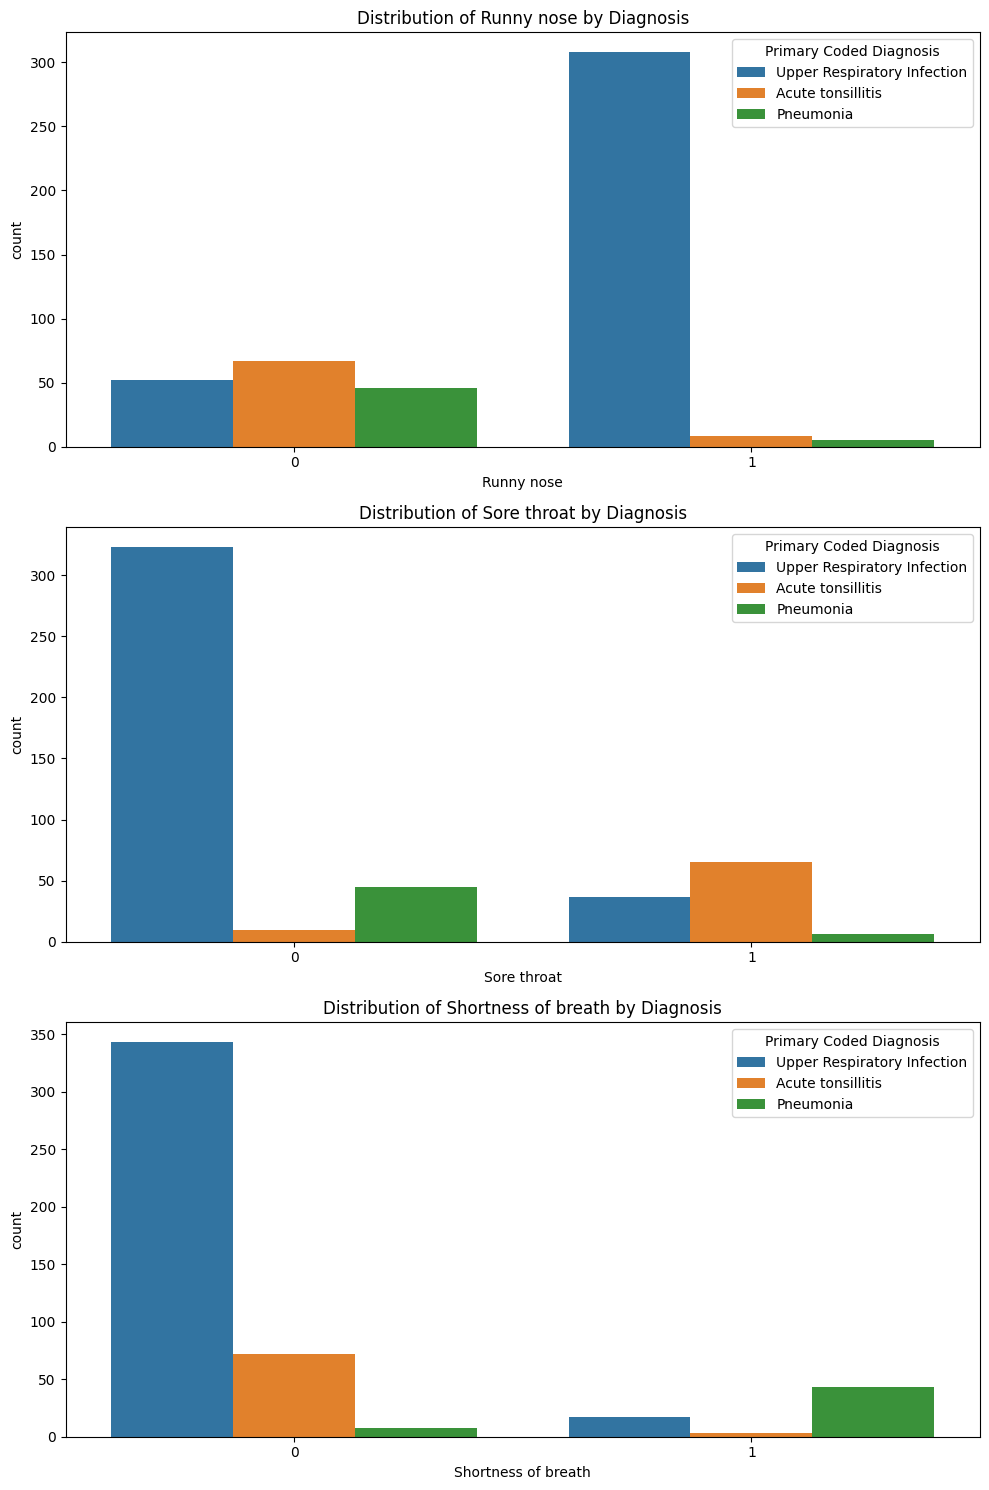

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(10, 15))

sns.countplot(x='Runny nose', hue='Primary Coded Diagnosis', data=data, ax=axes[0])
axes[0].set_title("Distribution of Runny nose by Diagnosis")

sns.countplot(x='Sore throat', hue='Primary Coded Diagnosis', data=data, ax=axes[1])
axes[1].set_title("Distribution of Sore throat by Diagnosis")

sns.countplot(x='Shortness of breath', hue='Primary Coded Diagnosis', data=data, ax=axes[2])
axes[2].set_title("Distribution of Shortness of breath by Diagnosis")

plt.tight_layout()
plt.show()

# Task
Build a classification model to predict the 'Primary Coded Diagnosis' using all other features in the dataset, and evaluate its performance.

## Prepare the data for modeling

### Subtask:
Split the data into features (X) and target (y), and then split these into training and testing sets.


**Reasoning**:
Split the data into features (X) and target (y), and then split these into training and testing sets.



In [18]:
X = data.drop('Primary Coded Diagnosis', axis=1)
y = data['Primary Coded Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [19]:
model=LogisticRegression()

In [20]:
#Training the model
model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [21]:
#Testing the model using the test data
y_pred=model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print("Accuracy:", accuracy)
print("Confusion matrix:",conf_matrix)
print("Class report:", class_report)

Accuracy: 0.910958904109589
Confusion matrix: [[ 17   0   6]
 [  1  16   3]
 [  3   0 100]]
Class report:                              precision    recall  f1-score   support

          Acute tonsillitis       0.81      0.74      0.77        23
                  Pneumonia       1.00      0.80      0.89        20
Upper Respiratory Infection       0.92      0.97      0.94       103

                   accuracy                           0.91       146
                  macro avg       0.91      0.84      0.87       146
               weighted avg       0.91      0.91      0.91       146



Based on the output, the model's performance is generally quite good, but there are a few things to consider:

Overall Accuracy (0.911): An accuracy of over 91% is quite high, meaning the model correctly predicted the diagnosis for about 91% of the cases in the test set. This is a strong indicator of good performance.
Confusion Matrix: The confusion matrix shows how well the model predicted each specific diagnosis:
Upper Respiratory Infection: The model did very well here, correctly predicting 100 cases and only misclassifying 3 as Acute tonsillitis.
Pneumonia: The model also performed well for Pneumonia, correctly predicting 16 cases and misclassifying 3 as Acute tonsillitis and 1 as Upper Respiratory Infection.
Acute tonsillitis: The model had the most difficulty with Acute tonsillitis, correctly predicting only 17 cases, while misclassifying 6 as Upper Respiratory Infection and 0 as Pneumonia.
Classification Report: This report provides more detailed metrics for each class:
Precision: For Pneumonia, the precision is 1.00, meaning that when the model predicted Pneumonia, it was always correct. For Acute tonsillitis, the precision is 0.81, meaning that 81% of the times the model predicted Acute tonsillitis, it was correct.
Recall: For Upper Respiratory Infection, the recall is 0.97, meaning the model correctly identified 97% of the actual Upper Respiratory Infection cases. For Acute tonsillitis, the recall is 0.74, meaning the model only identified 74% of the actual Acute tonsillitis cases.
F1-score: This is a balanced metric considering both precision and recall. The F1-scores are high for Upper Respiratory Infection (0.94) and Pneumonia (0.89), but slightly lower for Acute tonsillitis (0.77).
In summary:

The model is good at predicting Upper Respiratory Infection and Pneumonia, with high accuracy, precision, and recall for these classes. However, it is less effective at identifying Acute tonsillitis cases, as indicated by the lower recall and F1-score for this class. This suggests the model might be biased towards predicting the more frequent diagnoses (Upper Respiratory Infection appears to be the most common in the dataset based on the confusion matrix counts).

To determine if this performance is "good" enough depends on the specific application and the acceptable trade-offs between correctly identifying each diagnosis.

In [22]:
import joblib
joblib_file = "/content/drive/MyDrive/engage2/Internship project/logistic_regression_model.joblib"
joblib.dump(model, joblib_file)

['/content/drive/MyDrive/engage2/Internship project/logistic_regression_model.joblib']

In [23]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 121.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 115.8 MB/s eta 0:00:00


In [24]:
import streamlit as st
import joblib
import pandas as pd

# Load the trained model
model = joblib.load("/content/drive/MyDrive/engage2/Internship project/logistic_regression_model.joblib")

st.title("Upper Respiratory Tract Infection Diagnosis Predictor")

st.write("Enter the patient's information to predict the diagnosis.")

# Create input fields for features
age = st.number_input("Age", min_value=0, max_value=100, value=25)
gender = st.selectbox("Gender", options=[0, 1], format_func=lambda x: 'Female' if x == 1 else 'Male')
fever = st.selectbox("Fever", options=[0, 1], format_func=lambda x: 'Yes' if x == 1 else 'No')
cough = st.selectbox("Cough", options=[0, 1], format_func=lambda x: 'Yes' if x == 1 else 'No')
runny_nose = st.selectbox("Runny nose", options=[0, 1], format_func=lambda x: 'Yes' if x == 1 else 'No')
sore_throat = st.selectbox("Sore throat", options=[0, 1], format_func=lambda x: 'Yes' if x == 1 else 'No')
shortness_of_breath = st.selectbox("Shortness of breath", options=[0, 1], format_func=lambda x: 'Yes' if x == 1 else 'No')

# Create a button to make predictions
if st.button("Predict Diagnosis"):
    # Create a DataFrame from the input values
    input_data = pd.DataFrame([[age, gender, fever, cough, runny_nose, sore_throat, shortness_of_breath]],
                               columns=['Age', 'Gender', 'Fever', 'Cough', 'Runny nose', 'Sore throat', 'Shortness of breath'])

    # Make prediction
    prediction = model.predict(input_data)

    st.write(f"Predicted Diagnosis: {prediction[0]}")

2026-06-24 10:09:07.409 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-24 10:09:08.253 
  command:

    streamlit run /usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py [ARGUMENTS]
2026-06-24 10:09:08.258 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-24 10:09:08.262 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-24 10:09:08.270 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-24 10:09:08.274 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-24 10:09:08.278 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-24 10:09:08.283 Thread 'MainThread': mi